11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.3398 - val_loss: 0.2080
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1963 - val_loss: 0.1727
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1711 - val_loss: 0.1608
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1590 - val_loss: 0.1519
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1519 - val_loss: 0.1478
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1480 - val_loss: 0.1447
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1445 - val_loss: 0.1419
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.1417 - val_loss: 0.1403
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1399 - val_loss: 0.1382
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1380 - val_loss: 0.1362

Final Training Entropy Loss: 0.13784824311733246
Final Validation Entropy Loss: 0.13623394072055817
313/313 ━━━━━━━━━━━━━━━━━━━━

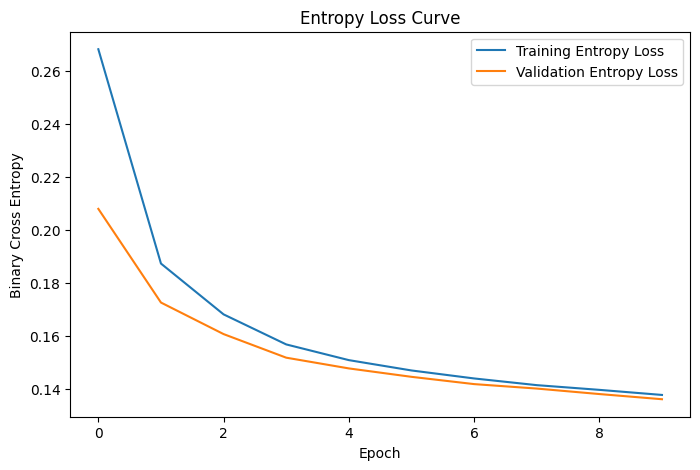

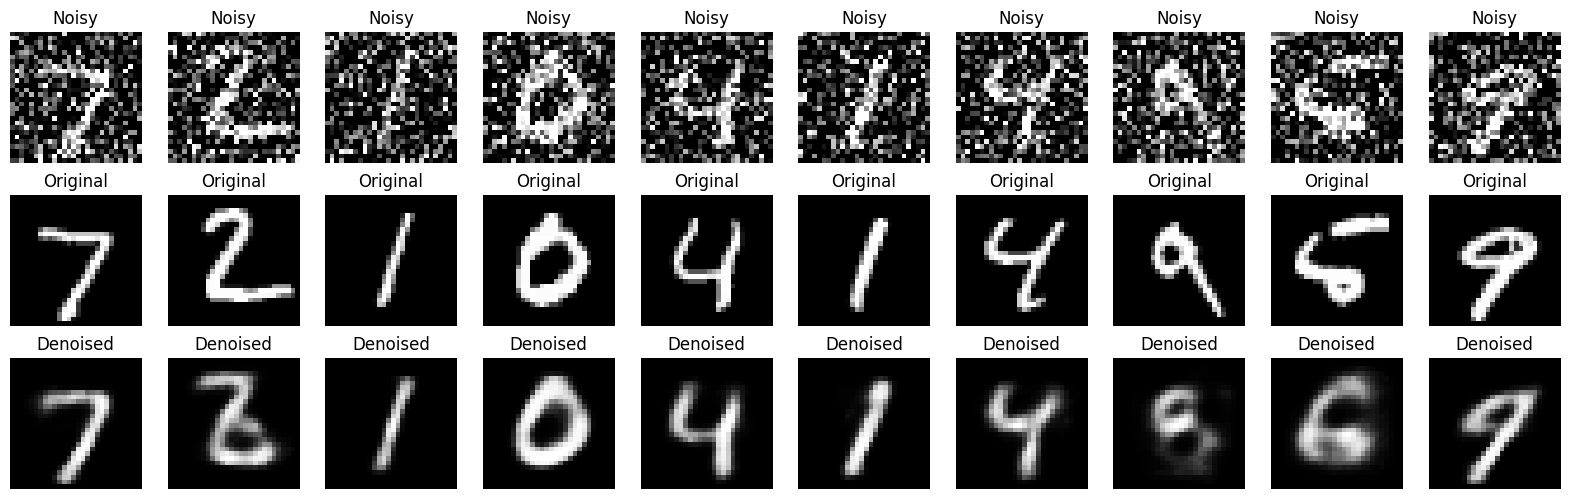

In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# ==============================
# 2. Load Dataset
# ==============================
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize images (0 to 1)
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Reshape to (samples, 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# ==============================
# 3. Add Noise
# ==============================
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# Clip values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# ==============================
# 4. Build Autoencoder
# ==============================

# Encoder
input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

# Combine
autoencoder = models.Model(input_img, decoded)

# Compile with Binary Cross Entropy (Entropy Loss)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

# ==============================
# 5. Train Model
# ==============================

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

# Print final entropy losses
print("\nFinal Training Entropy Loss:", history.history['loss'][-1])
print("Final Validation Entropy Loss:", history.history['val_loss'][-1])

# ==============================
# 6. Predict (Reconstruction)
# ==============================

decoded_imgs = autoencoder.predict(x_test_noisy)

# ==============================
# 7. Manual Entropy (Binary Cross Entropy) Calculation
# ==============================

epsilon = 1e-7
decoded_imgs_clipped = np.clip(decoded_imgs, epsilon, 1 - epsilon)

manual_bce = -np.mean(
    x_test * np.log(decoded_imgs_clipped) +
    (1 - x_test) * np.log(1 - decoded_imgs_clipped)
)

print("\nManual Binary Cross Entropy Loss:", manual_bce)

# ==============================
# 8. Plot Entropy Loss Curve
# ==============================

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Entropy Loss')
plt.plot(history.history['val_loss'], label='Validation Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross Entropy')
plt.title('Entropy Loss Curve')
plt.legend()
plt.show()

# ==============================
# 9. Visualize Results
# ==============================

n = 10
plt.figure(figsize=(20, 6))

for i in range(n):

    # Noisy
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Original
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.show()

In [ ]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 26.77 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/content/pytorch-CycleGAN-and-pix2pix


In [ ]:
!pip install dominate
!pip install visdom

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for visdom: filename=visdom-0.2.4-py3-none-any.whl size=1408195 sha256=d4793afabe6ea680d9e10b9ce771b8a5e7aa4424005e31975a05333d5262a00e
  Stored in directory: /root/.cache/pip/wheels/37/6c/38/64eeaa310e325aacda723e6df1f79ab5e9f31ba195264e04a8
Successfully built visdom


In [ ]:
import torch
print(torch.__version__)

2.10.0+cpu


In [ ]:
!bash ./scripts/download_cyclegan_model.sh horse2zebra

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [horse2zebra]
for details.

--2026-03-01 13:19:43--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/horse2zebra.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/horse2zebra_pretrained/latest_net_G.pth’

./checkpoints/horse 100%[===================>]  43.46M  25.9MB/s    in 1.7s    

2026-03-01 13:19:45 (25.9 MB/s) - ‘./checkpoints/horse2zebra_pretrained/latest_net_G.pth’ saved [45575747/45575747]



In [ ]:
!bash ./datasets/download_cyclegan_dataset.sh horse2zebra

Specified [horse2zebra]
for details.

--2026-03-01 13:20:00--  http://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 116867962 (111M) [application/zip]
Saving to: ‘./datasets/horse2zebra.zip’

./datasets/horse2ze 100%[===================>] 111.45M  3.72MB/s    in 43s     

2026-03-01 13:20:44 (2.57 MB/s) - ‘./datasets/horse2zebra.zip’ saved [116867962/116867962]

Archive:  ./datasets/horse2zebra.zip
   creating: ./datasets/horse2zebra/trainA/
  inflating: ./datasets/horse2zebra/trainA/n02381460_6223.jpg  
  inflating: ./datasets/horse2zebra/trainA/n02381460_1567.jpg  
  inflating: ./datasets/horse2zebra/trainA/n02381460_3354.jpg  
  inflating: ./datasets/horse2zebra/trainA/n02381460_299.jpg  
  inflating: ./datasets/horse2zebra/t

In [ ]:
!python test.py --dataroot ./datasets/horse2zebra \
                --name horse2zebra_pretrained \
                --model test \
                --no_dropout

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./datasets/horse2zebra        	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

In [ ]:
import os

path = "results/horse2zebra_pretrained/test_latest/images"
print(os.listdir(path))

['n02381460_2150_real.png', 'n02381460_2460_fake.png', 'n02381460_1100_fake.png', 'n02381460_200_fake.png', 'n02381460_1920_fake.png', 'n02381460_1160_real.png', 'n02381460_1260_fake.png', 'n02381460_1420_real.png', 'n02381460_2580_real.png', 'n02381460_1120_real.png', 'n02381460_1360_fake.png', 'n02381460_1110_fake.png', 'n02381460_1820_fake.png', 'n02381460_2580_fake.png', 'n02381460_1010_fake.png', 'n02381460_1350_fake.png', 'n02381460_1360_real.png', 'n02381460_1210_real.png', 'n02381460_1300_fake.png', 'n02381460_3120_real.png', 'n02381460_3010_real.png', 'n02381460_2890_real.png', 'n02381460_1100_real.png', 'n02381460_1300_real.png', 'n02381460_140_fake.png', 'n02381460_180_real.png', 'n02381460_2120_real.png', 'n02381460_2940_fake.png', 'n02381460_3010_fake.png', 'n02381460_3120_fake.png', 'n02381460_180_fake.png', 'n02381460_2100_fake.png', 'n02381460_1740_fake.png', 'n02381460_2540_fake.png', 'n02381460_3110_real.png', 'n02381460_1870_fake.png', 'n02381460_2120_fake.png', 'n02

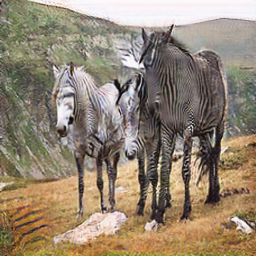

In [ ]:
from IPython.display import Image
Image(filename='results/horse2zebra_pretrained/test_latest/images/n02381460_2460_fake.png')